In [ ]:
# 1. Upgrade pip to ensure smooth dependency resolution
!pip install --upgrade pip

# 2. Install TensorFlow (Core backend dependency)
!pip install tensorflow

# 3. Install PyTorch (CPU version by default)
!pip install torch torchvision torchaudio

# 4. Install Keras 
!pip install --upgrade keras

In [38]:
import pandas as pd
dataset = pd.read_csv("sign_lang_mnist/sign_mnist_train/sign_mnist_train.csv")

In [56]:
import string
alphabet = {index:letter for index, letter in enumerate(string.ascii_lowercase)} 

In [ ]:
from sklearn.model_selection import train_test_split
prex = dataset.drop(columns=["label"])
X = prex.to_numpy().reshape(-1,28,28)
y = dataset["label"].to_numpy()
print(y[3])
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

2
22


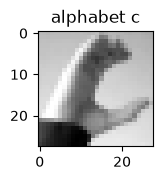

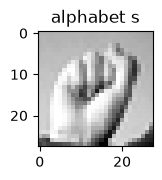

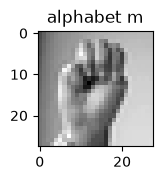

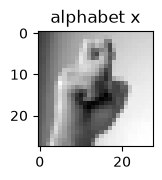

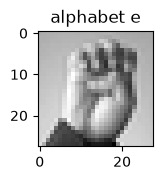

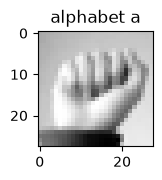

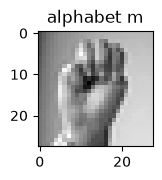

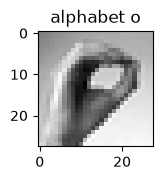

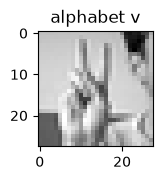

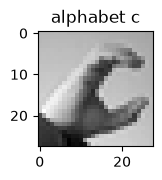

In [58]:
import matplotlib.pyplot as plt
import random

sow = [random.randint(0,len(X_train)-1) for i in range(10)]

for i in sow:
    img = X_train[i]
    label = y_train[i]
    plt.figure(figsize=(50,50))

    plt.subplot(28, 28, 1)        
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(f"alphabet {alphabet.get(label,'unknown')}")

In [59]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Initialize a sequential model
model = models.Sequential()

# 2. Add the Convolutional Base (Feature Extraction)
# First layer needs the explicit input shape (e.g., 64x64 pixel images with 3 color channels)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolutional block
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# 3. Add the Classifier Head
# Flatten the 3D feature maps into a 1D vector
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(26, activation='softmax')) # 26 output nodes for 26 classes

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print the complete network structure
model.summary()

/home/rohan/Desktop/FUN-Projects/MLFromScratch/scratchmlenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,970 (480.35 KB)

 Trainable params: 122,970 (480.35 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.1204 - loss: 3.3130 - val_accuracy: 0.1910 - val_loss: 2.6096
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4754 - loss: 1.6366 - val_accuracy: 0.7804 - val_loss: 0.6507
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9185 - loss: 0.2597 - val_accuracy: 0.9880 - val_loss: 0.0596
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9903 - loss: 0.0441 - val_accuracy: 0.9978 - val_loss: 0.0146
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9912 - loss: 0.0339 - val_accuracy: 0.9960 - val_loss: 0.0208


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


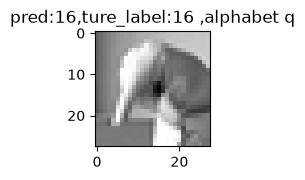

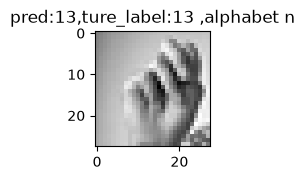

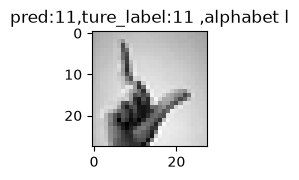

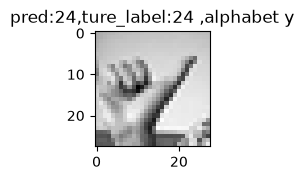

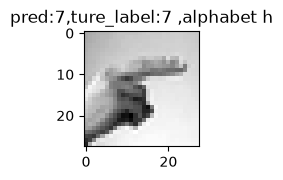

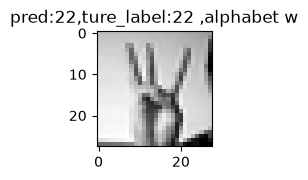

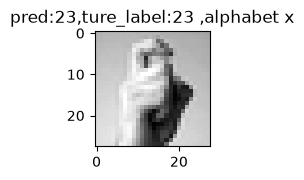

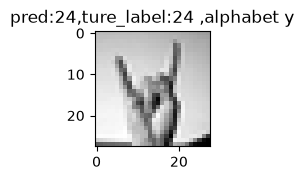

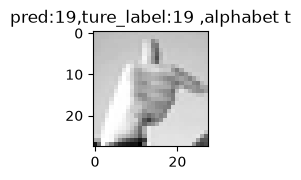

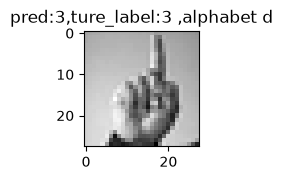

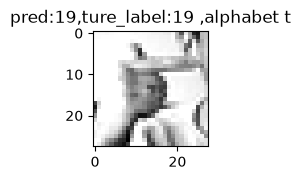

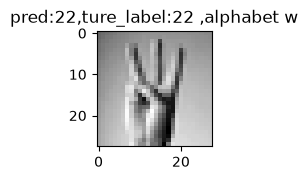

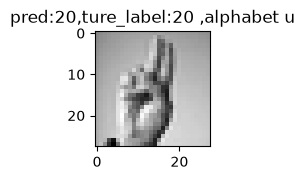

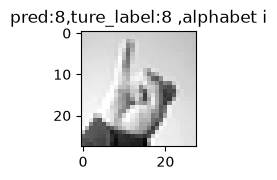

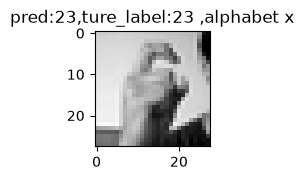

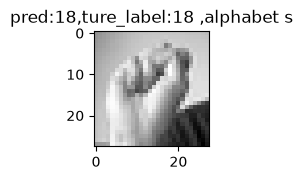

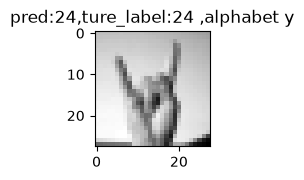

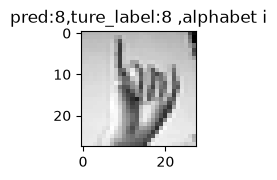

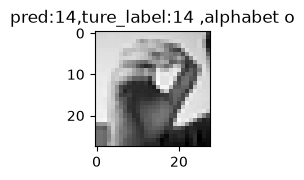

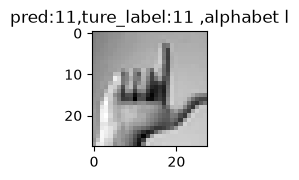

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import random

sow = [random.randint(0,len(X_test)-1) for i in range(20)]

for i in sow:
    img = X_test[i]
    label = y_test[i]

    pred = np.argmax(model.predict(X_test[i:i+1]))
    
    plt.figure(figsize=(50,50))

    plt.subplot(28, 28, 1)        
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(f"pred:{pred},ture_label:{label} ,alphabet {alphabet.get(label,'unknown')}")